# 2.1 Dendrogram

### 1. Importing Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
path = r'C:\Users\isava\OneDrive\Documents\CareerFoundry\MachineLearning\ClimateWins\02 Data\OriginalData'

In [3]:
#col_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(os.path.join(path, 'Dataset-weather-prediction-dataset-processed.csv'))
ans = pd.read_csv(os.path.join(path, 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))
df_scaled = pd.read_csv(os.path.join(path, 'Dataset-weather-prediction-dataset-processed-scaled.csv'))
df.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,2.1,0.85,1.018,0.32,0.09,0,0.7,...,5,0.88,1.0003,0.45,0.34,0,4.7,8.5,6.0,10.9
1,19600102,1,6,2.1,0.84,1.018,0.36,1.05,0,1.1,...,7,0.91,1.0007,0.25,0.84,0,0.7,8.9,5.6,12.1
2,19600103,1,8,2.1,0.90,1.018,0.18,0.30,0,0.0,...,7,0.91,1.0096,0.17,0.08,0,0.1,10.5,8.1,12.9
3,19600104,1,3,2.1,0.92,1.018,0.58,0.00,0,4.1,...,7,0.86,1.0184,0.13,0.98,0,0.0,7.4,7.3,10.6
4,19600105,1,6,2.1,0.95,1.018,0.65,0.14,0,5.4,...,3,0.80,1.0328,0.46,0.00,0,5.7,5.7,3.0,8.4


In [8]:
df.shape

(22950, 170)

In [12]:
ans.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### 2. Data wrangling

##### Reducing  the data set down to 1 year- 2010

In [7]:
df2000 = df_scaled[df_scaled['DATE'].astype(str).str.contains('2000')] #<-----INSERT YEAR HERE
df2000 = df2000.loc[:, ~df2000.columns.str.contains('^Unnamed')]

In [127]:
ans2000 = ans[ans['DATE'].astype(str).str.contains('2000')] #<-----INSERT YEAR HERE
ans2000 = ans2000.loc[:, ~ans.columns.str.contains('^Unnamed')]
ans2000.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
14610,20000101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14611,20000102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14612,20000103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14613,20000104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14614,20000105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### 3. Dendrogram - Budapest and Madrid

####  3.1 Single Method

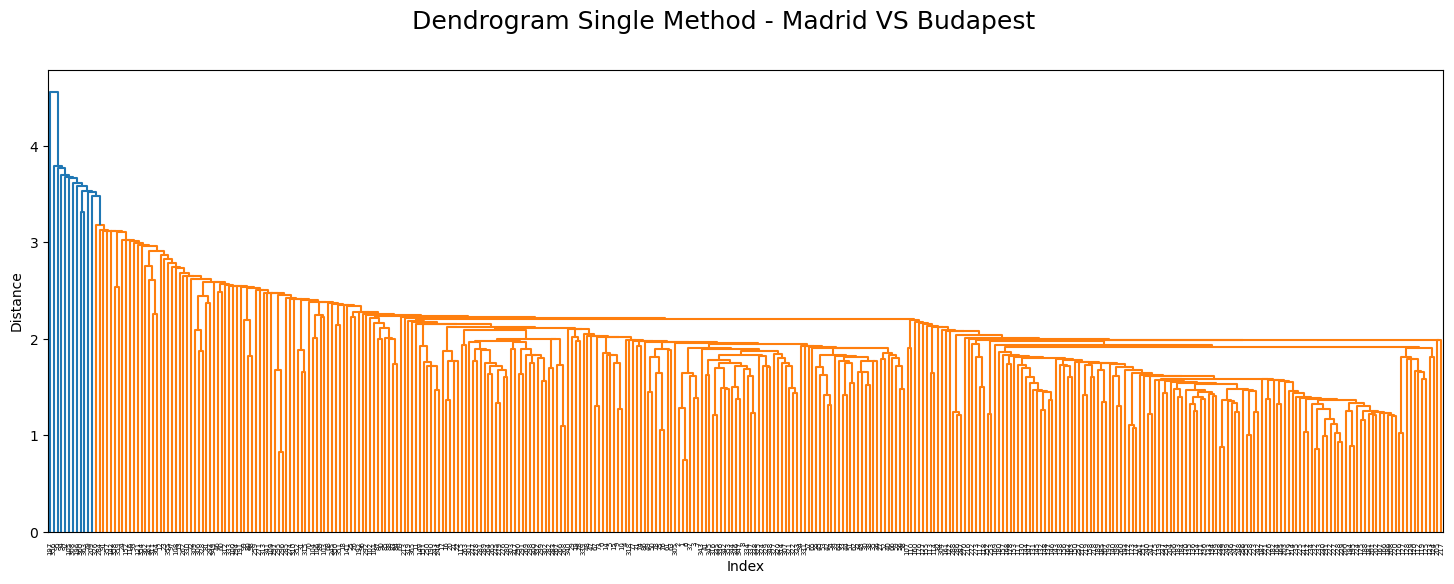

In [18]:
distance_single = linkage(df2000.loc[:,
['MADRID_cloud_cover',
 'MADRID_wind_speed',
 'MADRID_humidity',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',]],method="single")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method - Madrid VS Budapest",fontsize=18)
plt.show()

####  3.2 Complete Method

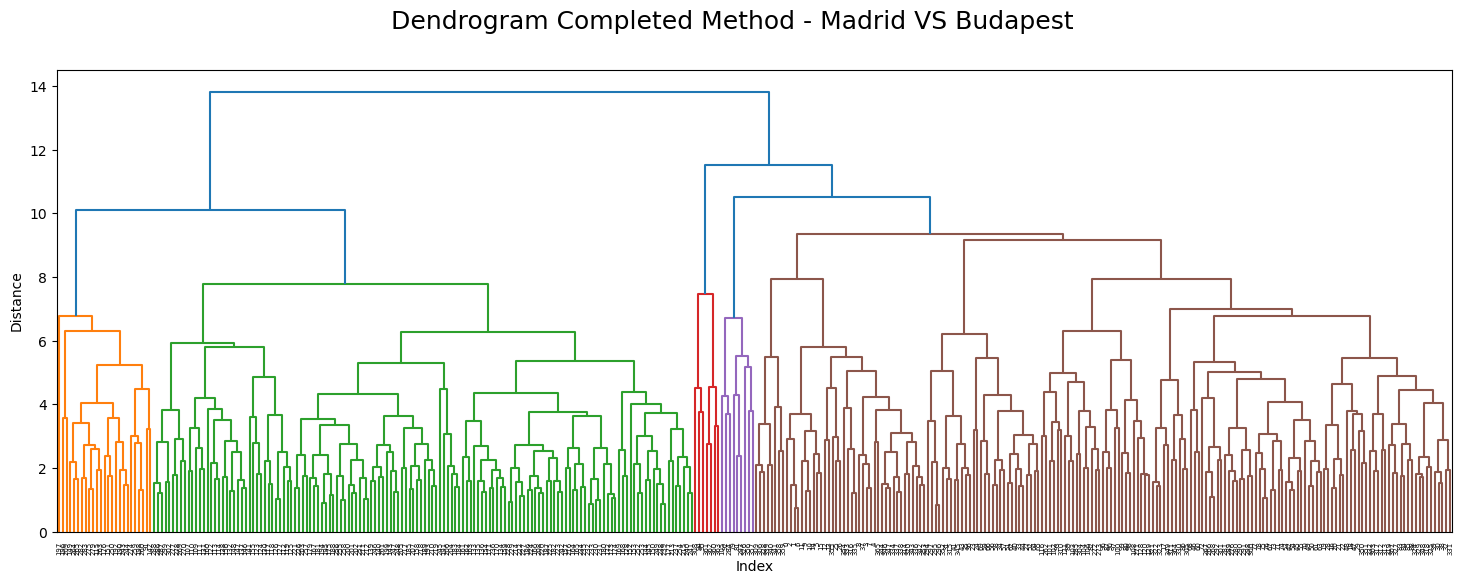

In [24]:
distance_single = linkage(df2000.loc[:,
['MADRID_cloud_cover',
 'MADRID_wind_speed',
 'MADRID_humidity',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',]],method="complete")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Completed Method - Madrid VS Budapest",fontsize=18)
plt.show()

####  3.3 Average Method

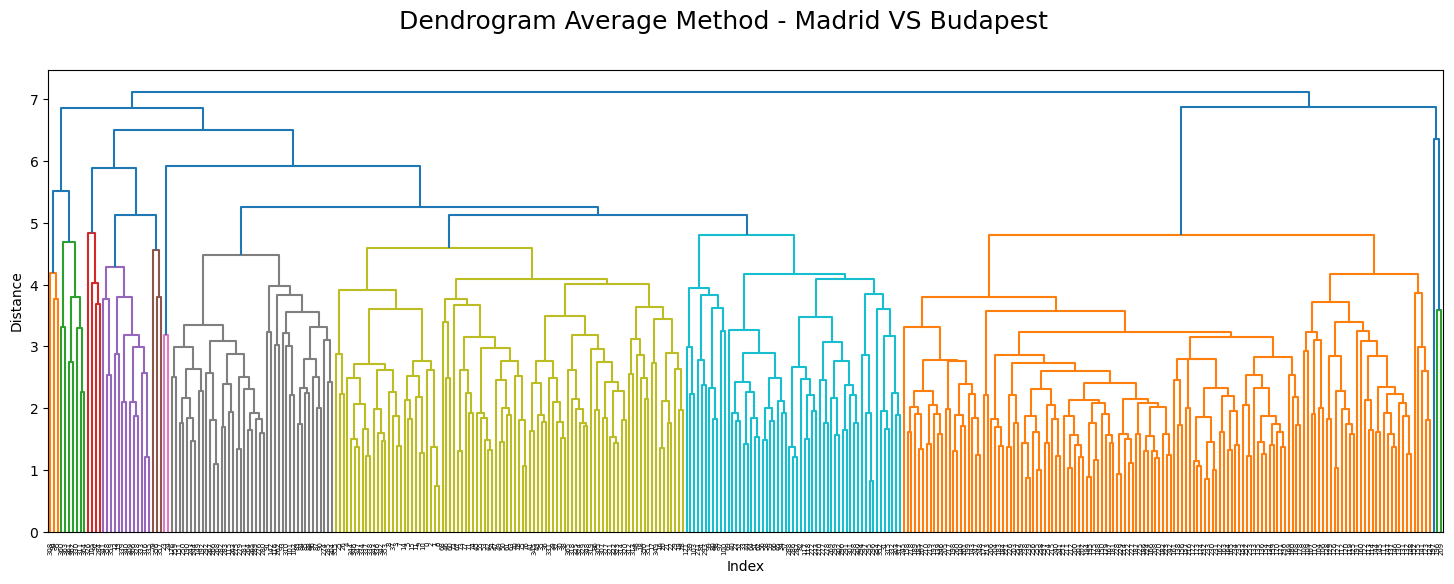

In [26]:
distance_single = linkage(df2000.loc[:,
['MADRID_cloud_cover',
 'MADRID_wind_speed',
 'MADRID_humidity',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',]],method="average")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method - Madrid VS Budapest",fontsize=18)
plt.show()

####  3.4 Ward Method

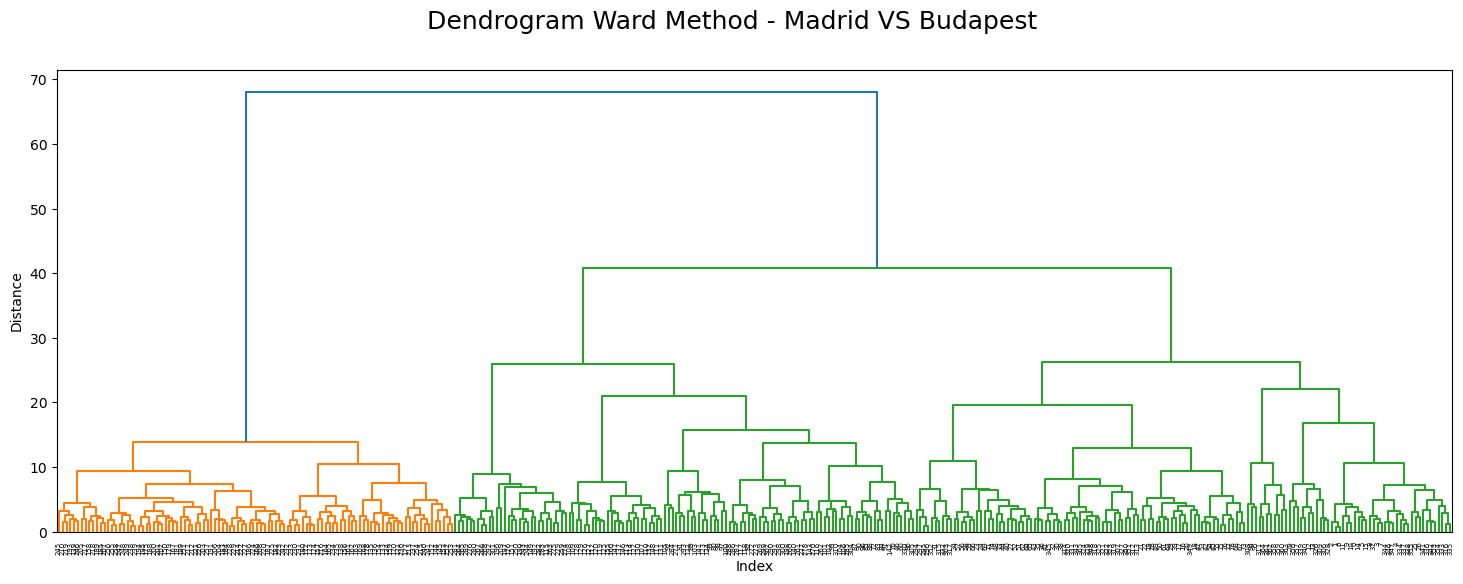

In [28]:
distance_single = linkage(df2000.loc[:,
['MADRID_cloud_cover',
 'MADRID_wind_speed',
 'MADRID_humidity',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',]],method="ward")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method - Madrid VS Budapest",fontsize=18)
plt.show()

### 4. Dendrogram - All stations

####  4.1 Single Method

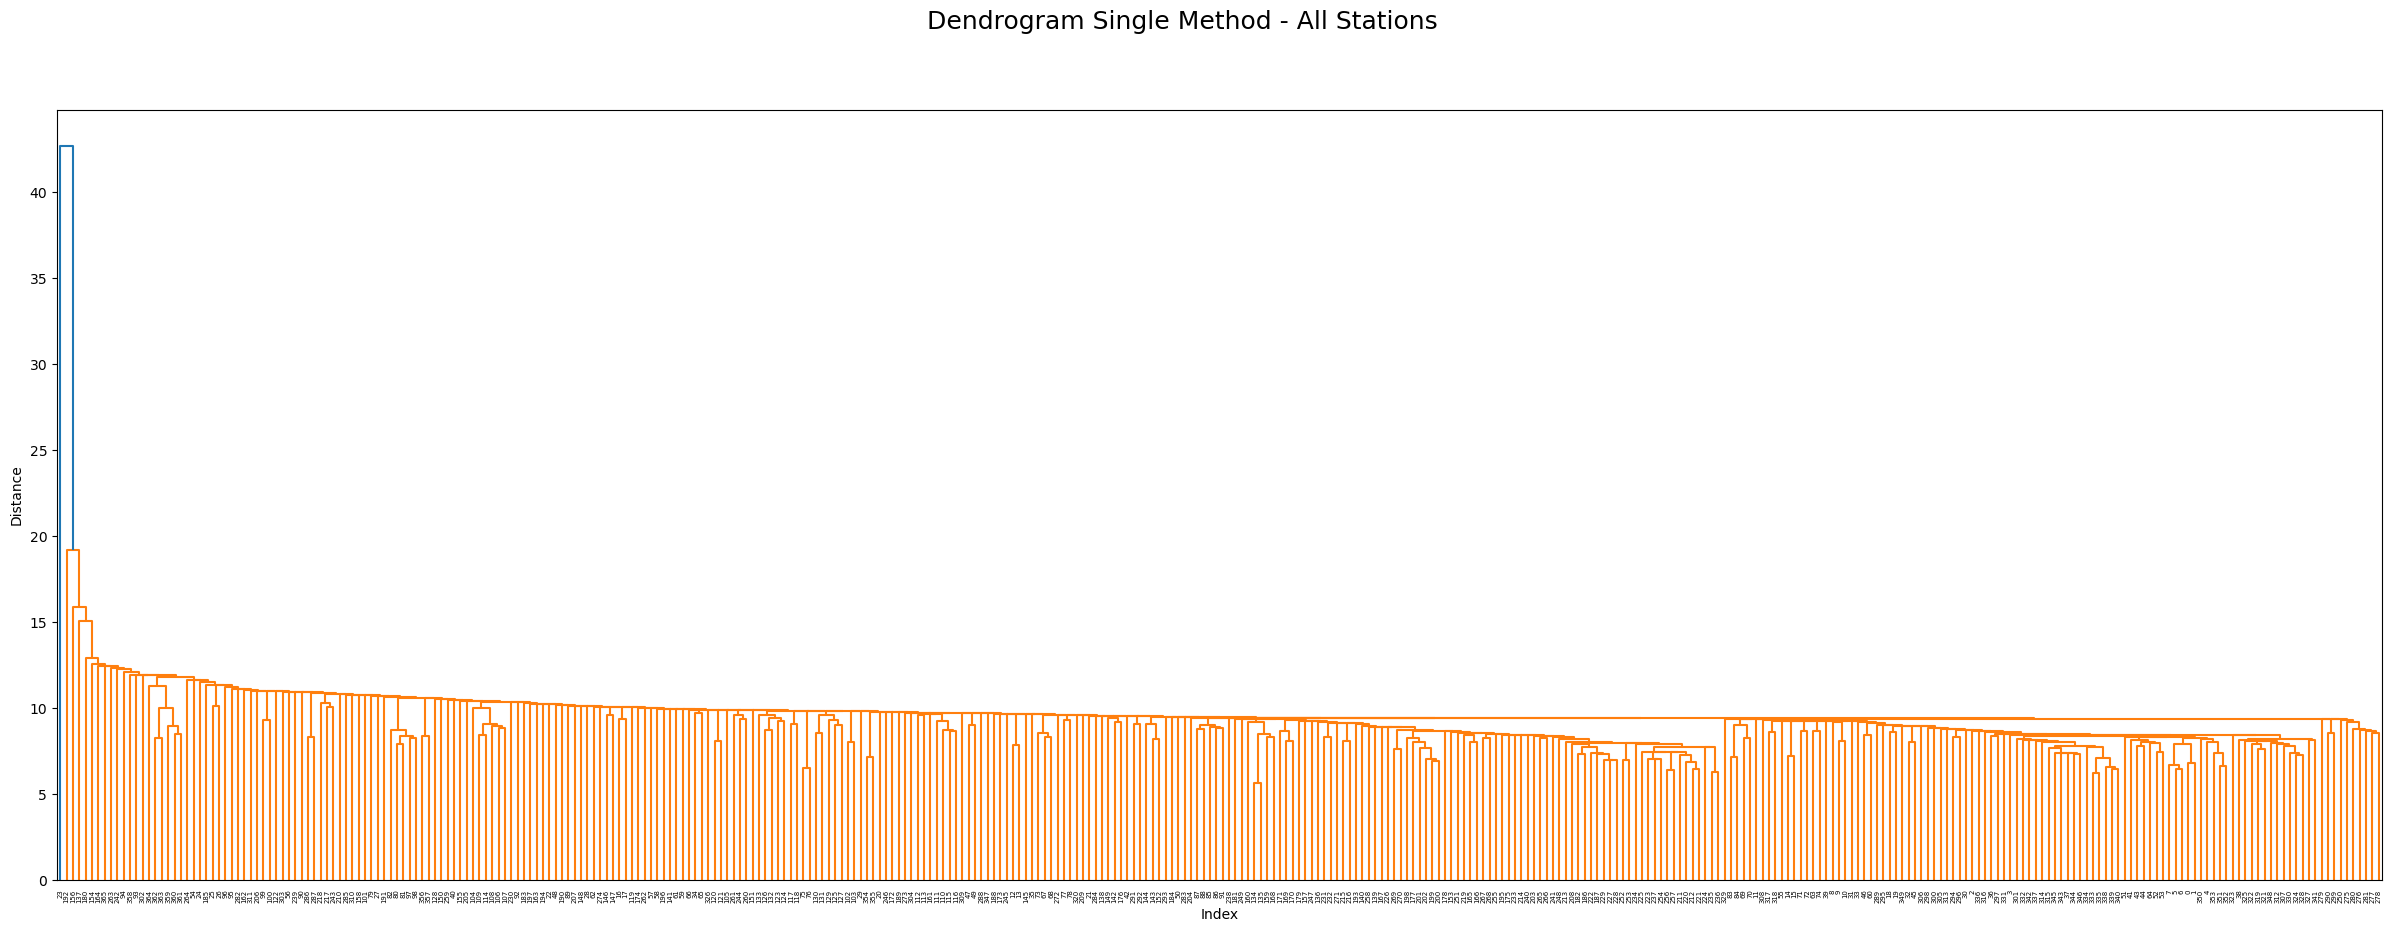

In [32]:
distance_single = linkage(df2000.loc[:,
['BASEL_cloud_cover',
 'BASEL_wind_speed',
 'BASEL_humidity',
 'BASEL_pressure',
 'BASEL_global_radiation',
 'BASEL_precipitation',
 'BASEL_snow_depth',
 'BASEL_sunshine',
 'BASEL_temp_mean',
 'BASEL_temp_min',
 'BASEL_temp_max',
 'BELGRADE_cloud_cover',
 'BELGRADE_humidity',
 'BELGRADE_pressure',
 'BELGRADE_global_radiation',
 'BELGRADE_precipitation',
 'BELGRADE_sunshine',
 'BELGRADE_temp_mean',
 'BELGRADE_temp_min',
 'BELGRADE_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',
 'DEBILT_cloud_cover',
 'DEBILT_wind_speed',
 'DEBILT_humidity',
 'DEBILT_pressure',
 'DEBILT_global_radiation',
 'DEBILT_precipitation',
 'DEBILT_sunshine',
 'DEBILT_temp_mean',
 'DEBILT_temp_min',
 'DEBILT_temp_max',
 'DUSSELDORF_cloud_cover',
 'DUSSELDORF_wind_speed',
 'DUSSELDORF_humidity',
 'DUSSELDORF_pressure',
 'DUSSELDORF_global_radiation',
 'DUSSELDORF_precipitation',
 'DUSSELDORF_snow_depth',
 'DUSSELDORF_sunshine',
 'DUSSELDORF_temp_mean',
 'DUSSELDORF_temp_min',
 'DUSSELDORF_temp_max',
 'GDANSK_cloud_cover',
 'GDANSK_humidity',
 'GDANSK_precipitation',
 'GDANSK_snow_depth',
 'GDANSK_temp_mean',
 'GDANSK_temp_min',
 'GDANSK_temp_max',
 'HEATHROW_cloud_cover',
 'HEATHROW_humidity',
 'HEATHROW_pressure',
 'HEATHROW_global_radiation',
 'HEATHROW_precipitation',
 'HEATHROW_snow_depth',
 'HEATHROW_sunshine',
 'HEATHROW_temp_mean',
 'HEATHROW_temp_min',
 'HEATHROW_temp_max',
 'KASSEL_wind_speed',
 'KASSEL_humidity',
 'KASSEL_pressure',
 'KASSEL_global_radiation',
 'KASSEL_precipitation',
 'KASSEL_sunshine',
 'KASSEL_temp_mean',
 'KASSEL_temp_min',
 'KASSEL_temp_max',
 'LJUBLJANA_cloud_cover',
 'LJUBLJANA_wind_speed',
 'LJUBLJANA_humidity',
 'LJUBLJANA_pressure',
 'LJUBLJANA_global_radiation',
 'LJUBLJANA_precipitation',
 'LJUBLJANA_sunshine',
 'LJUBLJANA_temp_mean',
 'LJUBLJANA_temp_min',
 'LJUBLJANA_temp_max',
 'MAASTRICHT_cloud_cover',
 'MAASTRICHT_wind_speed',
 'MAASTRICHT_humidity',
 'MAASTRICHT_pressure',
 'MAASTRICHT_global_radiation',
 'MAASTRICHT_precipitation',
 'MAASTRICHT_sunshine',
 'MAASTRICHT_temp_mean',
 'MAASTRICHT_temp_min',
 'MAASTRICHT_temp_max',
 'MADRID_cloud_cover',
 'MADRID_wind_speed',
 'MADRID_humidity',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'MUNCHENB_cloud_cover',
 'MUNCHENB_humidity',
 'MUNCHENB_global_radiation',
 'MUNCHENB_precipitation',
 'MUNCHENB_snow_depth',
 'MUNCHENB_sunshine',
 'MUNCHENB_temp_mean',
 'MUNCHENB_temp_min',
 'MUNCHENB_temp_max',
 'OSLO_cloud_cover',
 'OSLO_wind_speed',
 'OSLO_humidity',
 'OSLO_pressure',
 'OSLO_global_radiation',
 'OSLO_precipitation',
 'OSLO_snow_depth',
 'OSLO_sunshine',
 'OSLO_temp_mean',
 'OSLO_temp_min',
 'OSLO_temp_max',
 'ROMA_cloud_cover',
 'ROMA_wind_speed',
 'ROMA_humidity',
 'ROMA_pressure',
 'ROMA_sunshine',
 'ROMA_temp_mean',
 'SONNBLICK_cloud_cover',
 'SONNBLICK_wind_speed',
 'SONNBLICK_humidity',
 'SONNBLICK_pressure',
 'SONNBLICK_global_radiation',
 'SONNBLICK_precipitation',
 'SONNBLICK_sunshine',
 'SONNBLICK_temp_mean',
 'SONNBLICK_temp_min',
 'SONNBLICK_temp_max',
 'STOCKHOLM_cloud_cover',
 'STOCKHOLM_pressure',
 'STOCKHOLM_global_radiation',
 'STOCKHOLM_precipitation',
 'STOCKHOLM_sunshine',
 'STOCKHOLM_temp_mean',
 'STOCKHOLM_temp_min',
 'STOCKHOLM_temp_max',
 'TOURS_wind_speed',
 'TOURS_humidity',
 'TOURS_pressure',
 'TOURS_global_radiation',
 'TOURS_precipitation',
 'TOURS_temp_mean',
 'TOURS_temp_min',
 'TOURS_temp_max',
 'VALENTIA_cloud_cover',
 'VALENTIA_humidity',
 'VALENTIA_pressure',
 'VALENTIA_global_radiation',
 'VALENTIA_precipitation',
 'VALENTIA_snow_depth',
 'VALENTIA_sunshine',
 'VALENTIA_temp_mean',
 'VALENTIA_temp_min',
 'VALENTIA_temp_max']],method="single")
plt.figure(figsize=(30,10))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method - All Stations",fontsize=18)
plt.show()

####  4.2 Complete Method

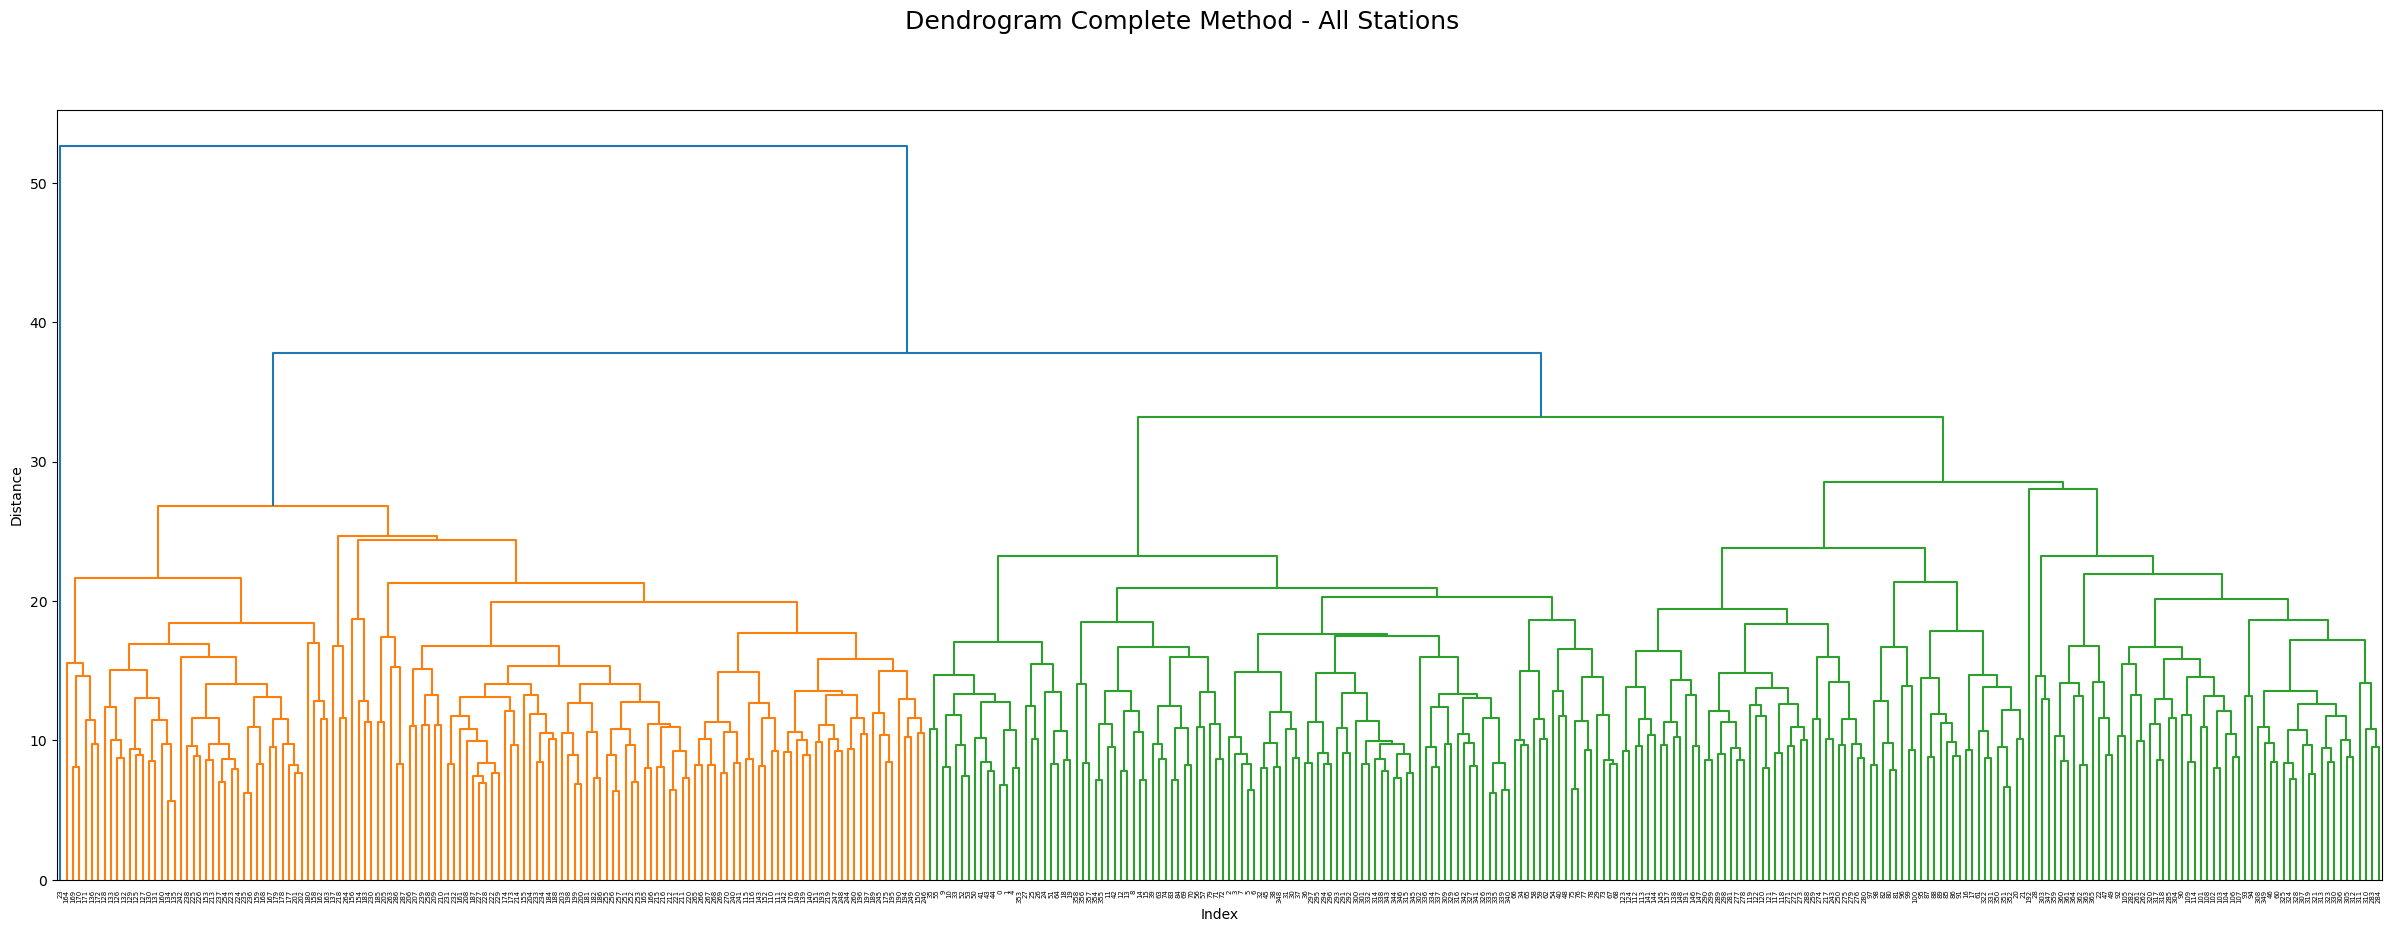

In [34]:
distance_single = linkage(df2000.loc[:,
['BASEL_cloud_cover',
 'BASEL_wind_speed',
 'BASEL_humidity',
 'BASEL_pressure',
 'BASEL_global_radiation',
 'BASEL_precipitation',
 'BASEL_snow_depth',
 'BASEL_sunshine',
 'BASEL_temp_mean',
 'BASEL_temp_min',
 'BASEL_temp_max',
 'BELGRADE_cloud_cover',
 'BELGRADE_humidity',
 'BELGRADE_pressure',
 'BELGRADE_global_radiation',
 'BELGRADE_precipitation',
 'BELGRADE_sunshine',
 'BELGRADE_temp_mean',
 'BELGRADE_temp_min',
 'BELGRADE_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',
 'DEBILT_cloud_cover',
 'DEBILT_wind_speed',
 'DEBILT_humidity',
 'DEBILT_pressure',
 'DEBILT_global_radiation',
 'DEBILT_precipitation',
 'DEBILT_sunshine',
 'DEBILT_temp_mean',
 'DEBILT_temp_min',
 'DEBILT_temp_max',
 'DUSSELDORF_cloud_cover',
 'DUSSELDORF_wind_speed',
 'DUSSELDORF_humidity',
 'DUSSELDORF_pressure',
 'DUSSELDORF_global_radiation',
 'DUSSELDORF_precipitation',
 'DUSSELDORF_snow_depth',
 'DUSSELDORF_sunshine',
 'DUSSELDORF_temp_mean',
 'DUSSELDORF_temp_min',
 'DUSSELDORF_temp_max',
 'GDANSK_cloud_cover',
 'GDANSK_humidity',
 'GDANSK_precipitation',
 'GDANSK_snow_depth',
 'GDANSK_temp_mean',
 'GDANSK_temp_min',
 'GDANSK_temp_max',
 'HEATHROW_cloud_cover',
 'HEATHROW_humidity',
 'HEATHROW_pressure',
 'HEATHROW_global_radiation',
 'HEATHROW_precipitation',
 'HEATHROW_snow_depth',
 'HEATHROW_sunshine',
 'HEATHROW_temp_mean',
 'HEATHROW_temp_min',
 'HEATHROW_temp_max',
 'KASSEL_wind_speed',
 'KASSEL_humidity',
 'KASSEL_pressure',
 'KASSEL_global_radiation',
 'KASSEL_precipitation',
 'KASSEL_sunshine',
 'KASSEL_temp_mean',
 'KASSEL_temp_min',
 'KASSEL_temp_max',
 'LJUBLJANA_cloud_cover',
 'LJUBLJANA_wind_speed',
 'LJUBLJANA_humidity',
 'LJUBLJANA_pressure',
 'LJUBLJANA_global_radiation',
 'LJUBLJANA_precipitation',
 'LJUBLJANA_sunshine',
 'LJUBLJANA_temp_mean',
 'LJUBLJANA_temp_min',
 'LJUBLJANA_temp_max',
 'MAASTRICHT_cloud_cover',
 'MAASTRICHT_wind_speed',
 'MAASTRICHT_humidity',
 'MAASTRICHT_pressure',
 'MAASTRICHT_global_radiation',
 'MAASTRICHT_precipitation',
 'MAASTRICHT_sunshine',
 'MAASTRICHT_temp_mean',
 'MAASTRICHT_temp_min',
 'MAASTRICHT_temp_max',
 'MADRID_cloud_cover',
 'MADRID_wind_speed',
 'MADRID_humidity',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'MUNCHENB_cloud_cover',
 'MUNCHENB_humidity',
 'MUNCHENB_global_radiation',
 'MUNCHENB_precipitation',
 'MUNCHENB_snow_depth',
 'MUNCHENB_sunshine',
 'MUNCHENB_temp_mean',
 'MUNCHENB_temp_min',
 'MUNCHENB_temp_max',
 'OSLO_cloud_cover',
 'OSLO_wind_speed',
 'OSLO_humidity',
 'OSLO_pressure',
 'OSLO_global_radiation',
 'OSLO_precipitation',
 'OSLO_snow_depth',
 'OSLO_sunshine',
 'OSLO_temp_mean',
 'OSLO_temp_min',
 'OSLO_temp_max',
 'ROMA_cloud_cover',
 'ROMA_wind_speed',
 'ROMA_humidity',
 'ROMA_pressure',
 'ROMA_sunshine',
 'ROMA_temp_mean',
 'SONNBLICK_cloud_cover',
 'SONNBLICK_wind_speed',
 'SONNBLICK_humidity',
 'SONNBLICK_pressure',
 'SONNBLICK_global_radiation',
 'SONNBLICK_precipitation',
 'SONNBLICK_sunshine',
 'SONNBLICK_temp_mean',
 'SONNBLICK_temp_min',
 'SONNBLICK_temp_max',
 'STOCKHOLM_cloud_cover',
 'STOCKHOLM_pressure',
 'STOCKHOLM_global_radiation',
 'STOCKHOLM_precipitation',
 'STOCKHOLM_sunshine',
 'STOCKHOLM_temp_mean',
 'STOCKHOLM_temp_min',
 'STOCKHOLM_temp_max',
 'TOURS_wind_speed',
 'TOURS_humidity',
 'TOURS_pressure',
 'TOURS_global_radiation',
 'TOURS_precipitation',
 'TOURS_temp_mean',
 'TOURS_temp_min',
 'TOURS_temp_max',
 'VALENTIA_cloud_cover',
 'VALENTIA_humidity',
 'VALENTIA_pressure',
 'VALENTIA_global_radiation',
 'VALENTIA_precipitation',
 'VALENTIA_snow_depth',
 'VALENTIA_sunshine',
 'VALENTIA_temp_mean',
 'VALENTIA_temp_min',
 'VALENTIA_temp_max']],method="complete")
plt.figure(figsize=(30,10))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Complete Method - All Stations",fontsize=18)
plt.show()

####  4.3 Average Method

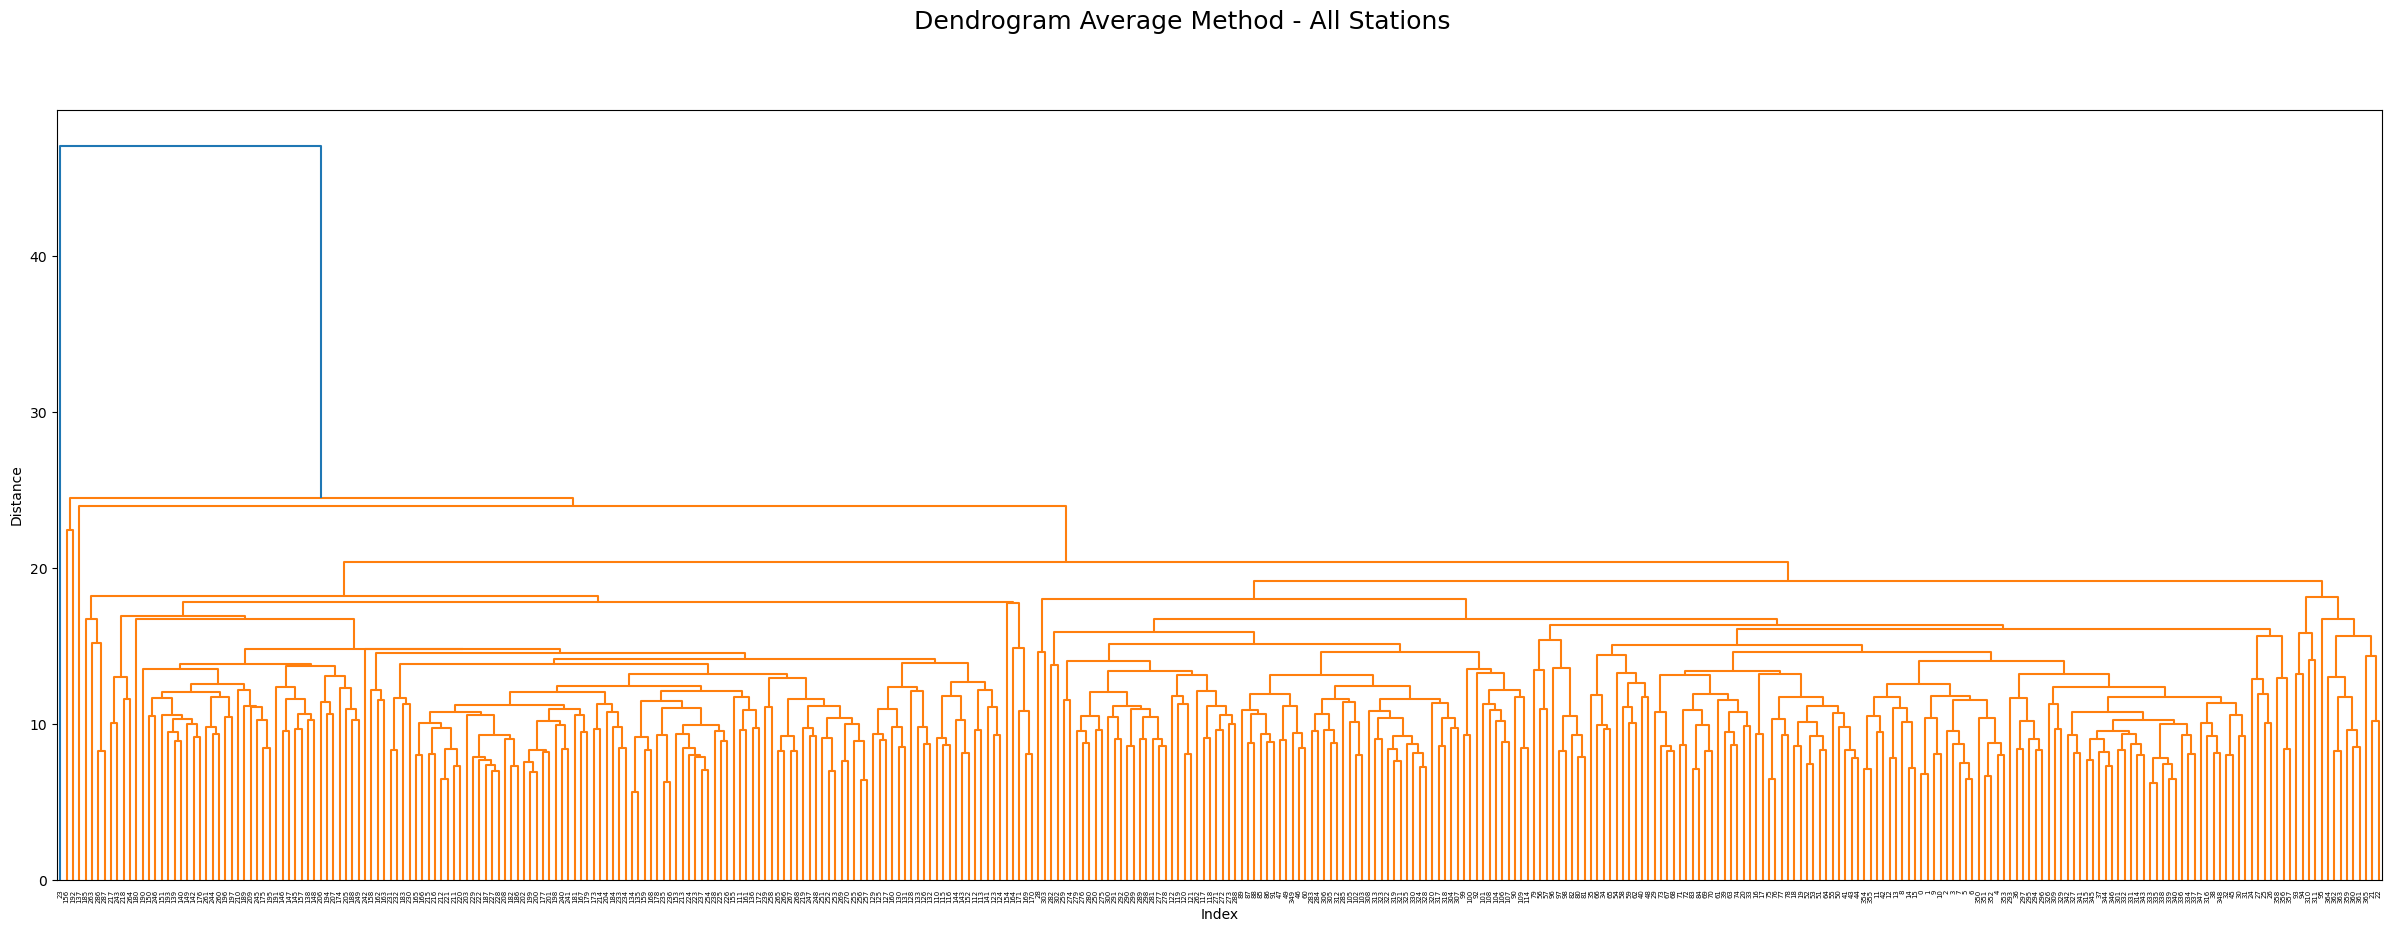

In [36]:
distance_single = linkage(df2000.loc[:,
['BASEL_cloud_cover',
 'BASEL_wind_speed',
 'BASEL_humidity',
 'BASEL_pressure',
 'BASEL_global_radiation',
 'BASEL_precipitation',
 'BASEL_snow_depth',
 'BASEL_sunshine',
 'BASEL_temp_mean',
 'BASEL_temp_min',
 'BASEL_temp_max',
 'BELGRADE_cloud_cover',
 'BELGRADE_humidity',
 'BELGRADE_pressure',
 'BELGRADE_global_radiation',
 'BELGRADE_precipitation',
 'BELGRADE_sunshine',
 'BELGRADE_temp_mean',
 'BELGRADE_temp_min',
 'BELGRADE_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',
 'DEBILT_cloud_cover',
 'DEBILT_wind_speed',
 'DEBILT_humidity',
 'DEBILT_pressure',
 'DEBILT_global_radiation',
 'DEBILT_precipitation',
 'DEBILT_sunshine',
 'DEBILT_temp_mean',
 'DEBILT_temp_min',
 'DEBILT_temp_max',
 'DUSSELDORF_cloud_cover',
 'DUSSELDORF_wind_speed',
 'DUSSELDORF_humidity',
 'DUSSELDORF_pressure',
 'DUSSELDORF_global_radiation',
 'DUSSELDORF_precipitation',
 'DUSSELDORF_snow_depth',
 'DUSSELDORF_sunshine',
 'DUSSELDORF_temp_mean',
 'DUSSELDORF_temp_min',
 'DUSSELDORF_temp_max',
 'GDANSK_cloud_cover',
 'GDANSK_humidity',
 'GDANSK_precipitation',
 'GDANSK_snow_depth',
 'GDANSK_temp_mean',
 'GDANSK_temp_min',
 'GDANSK_temp_max',
 'HEATHROW_cloud_cover',
 'HEATHROW_humidity',
 'HEATHROW_pressure',
 'HEATHROW_global_radiation',
 'HEATHROW_precipitation',
 'HEATHROW_snow_depth',
 'HEATHROW_sunshine',
 'HEATHROW_temp_mean',
 'HEATHROW_temp_min',
 'HEATHROW_temp_max',
 'KASSEL_wind_speed',
 'KASSEL_humidity',
 'KASSEL_pressure',
 'KASSEL_global_radiation',
 'KASSEL_precipitation',
 'KASSEL_sunshine',
 'KASSEL_temp_mean',
 'KASSEL_temp_min',
 'KASSEL_temp_max',
 'LJUBLJANA_cloud_cover',
 'LJUBLJANA_wind_speed',
 'LJUBLJANA_humidity',
 'LJUBLJANA_pressure',
 'LJUBLJANA_global_radiation',
 'LJUBLJANA_precipitation',
 'LJUBLJANA_sunshine',
 'LJUBLJANA_temp_mean',
 'LJUBLJANA_temp_min',
 'LJUBLJANA_temp_max',
 'MAASTRICHT_cloud_cover',
 'MAASTRICHT_wind_speed',
 'MAASTRICHT_humidity',
 'MAASTRICHT_pressure',
 'MAASTRICHT_global_radiation',
 'MAASTRICHT_precipitation',
 'MAASTRICHT_sunshine',
 'MAASTRICHT_temp_mean',
 'MAASTRICHT_temp_min',
 'MAASTRICHT_temp_max',
 'MADRID_cloud_cover',
 'MADRID_wind_speed',
 'MADRID_humidity',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'MUNCHENB_cloud_cover',
 'MUNCHENB_humidity',
 'MUNCHENB_global_radiation',
 'MUNCHENB_precipitation',
 'MUNCHENB_snow_depth',
 'MUNCHENB_sunshine',
 'MUNCHENB_temp_mean',
 'MUNCHENB_temp_min',
 'MUNCHENB_temp_max',
 'OSLO_cloud_cover',
 'OSLO_wind_speed',
 'OSLO_humidity',
 'OSLO_pressure',
 'OSLO_global_radiation',
 'OSLO_precipitation',
 'OSLO_snow_depth',
 'OSLO_sunshine',
 'OSLO_temp_mean',
 'OSLO_temp_min',
 'OSLO_temp_max',
 'ROMA_cloud_cover',
 'ROMA_wind_speed',
 'ROMA_humidity',
 'ROMA_pressure',
 'ROMA_sunshine',
 'ROMA_temp_mean',
 'SONNBLICK_cloud_cover',
 'SONNBLICK_wind_speed',
 'SONNBLICK_humidity',
 'SONNBLICK_pressure',
 'SONNBLICK_global_radiation',
 'SONNBLICK_precipitation',
 'SONNBLICK_sunshine',
 'SONNBLICK_temp_mean',
 'SONNBLICK_temp_min',
 'SONNBLICK_temp_max',
 'STOCKHOLM_cloud_cover',
 'STOCKHOLM_pressure',
 'STOCKHOLM_global_radiation',
 'STOCKHOLM_precipitation',
 'STOCKHOLM_sunshine',
 'STOCKHOLM_temp_mean',
 'STOCKHOLM_temp_min',
 'STOCKHOLM_temp_max',
 'TOURS_wind_speed',
 'TOURS_humidity',
 'TOURS_pressure',
 'TOURS_global_radiation',
 'TOURS_precipitation',
 'TOURS_temp_mean',
 'TOURS_temp_min',
 'TOURS_temp_max',
 'VALENTIA_cloud_cover',
 'VALENTIA_humidity',
 'VALENTIA_pressure',
 'VALENTIA_global_radiation',
 'VALENTIA_precipitation',
 'VALENTIA_snow_depth',
 'VALENTIA_sunshine',
 'VALENTIA_temp_mean',
 'VALENTIA_temp_min',
 'VALENTIA_temp_max']],method="average")
plt.figure(figsize=(30,10))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method - All Stations",fontsize=18)
plt.show()

####  4.4 Ward Method

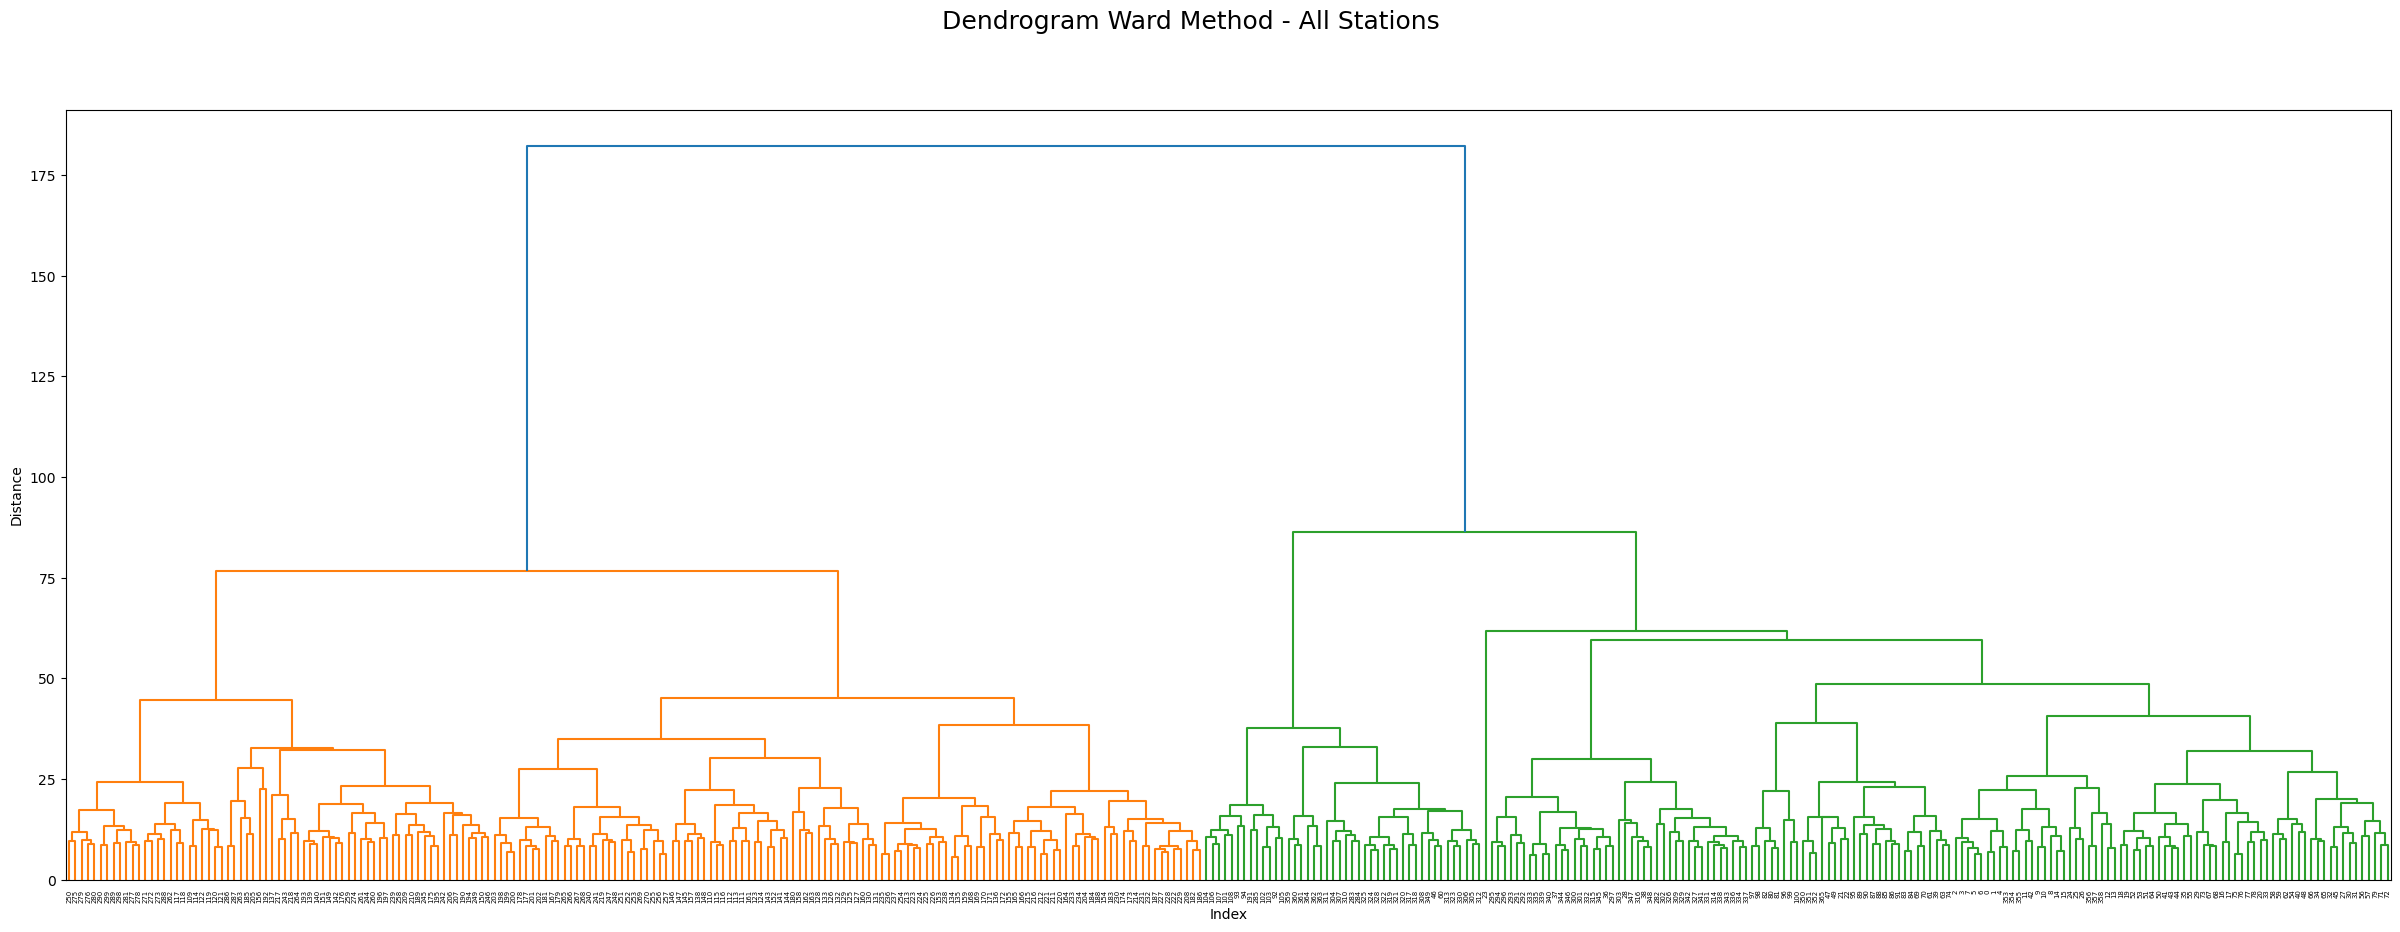

In [43]:
distance_single = linkage(df2000.loc[:,
['BASEL_cloud_cover',
 'BASEL_wind_speed',
 'BASEL_humidity',
 'BASEL_pressure',
 'BASEL_global_radiation',
 'BASEL_precipitation',
 'BASEL_snow_depth',
 'BASEL_sunshine',
 'BASEL_temp_mean',
 'BASEL_temp_min',
 'BASEL_temp_max',
 'BELGRADE_cloud_cover',
 'BELGRADE_humidity',
 'BELGRADE_pressure',
 'BELGRADE_global_radiation',
 'BELGRADE_precipitation',
 'BELGRADE_sunshine',
 'BELGRADE_temp_mean',
 'BELGRADE_temp_min',
 'BELGRADE_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',
 'DEBILT_cloud_cover',
 'DEBILT_wind_speed',
 'DEBILT_humidity',
 'DEBILT_pressure',
 'DEBILT_global_radiation',
 'DEBILT_precipitation',
 'DEBILT_sunshine',
 'DEBILT_temp_mean',
 'DEBILT_temp_min',
 'DEBILT_temp_max',
 'DUSSELDORF_cloud_cover',
 'DUSSELDORF_wind_speed',
 'DUSSELDORF_humidity',
 'DUSSELDORF_pressure',
 'DUSSELDORF_global_radiation',
 'DUSSELDORF_precipitation',
 'DUSSELDORF_snow_depth',
 'DUSSELDORF_sunshine',
 'DUSSELDORF_temp_mean',
 'DUSSELDORF_temp_min',
 'DUSSELDORF_temp_max',
 'GDANSK_cloud_cover',
 'GDANSK_humidity',
 'GDANSK_precipitation',
 'GDANSK_snow_depth',
 'GDANSK_temp_mean',
 'GDANSK_temp_min',
 'GDANSK_temp_max',
 'HEATHROW_cloud_cover',
 'HEATHROW_humidity',
 'HEATHROW_pressure',
 'HEATHROW_global_radiation',
 'HEATHROW_precipitation',
 'HEATHROW_snow_depth',
 'HEATHROW_sunshine',
 'HEATHROW_temp_mean',
 'HEATHROW_temp_min',
 'HEATHROW_temp_max',
 'KASSEL_wind_speed',
 'KASSEL_humidity',
 'KASSEL_pressure',
 'KASSEL_global_radiation',
 'KASSEL_precipitation',
 'KASSEL_sunshine',
 'KASSEL_temp_mean',
 'KASSEL_temp_min',
 'KASSEL_temp_max',
 'LJUBLJANA_cloud_cover',
 'LJUBLJANA_wind_speed',
 'LJUBLJANA_humidity',
 'LJUBLJANA_pressure',
 'LJUBLJANA_global_radiation',
 'LJUBLJANA_precipitation',
 'LJUBLJANA_sunshine',
 'LJUBLJANA_temp_mean',
 'LJUBLJANA_temp_min',
 'LJUBLJANA_temp_max',
 'MAASTRICHT_cloud_cover',
 'MAASTRICHT_wind_speed',
 'MAASTRICHT_humidity',
 'MAASTRICHT_pressure',
 'MAASTRICHT_global_radiation',
 'MAASTRICHT_precipitation',
 'MAASTRICHT_sunshine',
 'MAASTRICHT_temp_mean',
 'MAASTRICHT_temp_min',
 'MAASTRICHT_temp_max',
 'MADRID_cloud_cover',
 'MADRID_wind_speed',
 'MADRID_humidity',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'MUNCHENB_cloud_cover',
 'MUNCHENB_humidity',
 'MUNCHENB_global_radiation',
 'MUNCHENB_precipitation',
 'MUNCHENB_snow_depth',
 'MUNCHENB_sunshine',
 'MUNCHENB_temp_mean',
 'MUNCHENB_temp_min',
 'MUNCHENB_temp_max',
 'OSLO_cloud_cover',
 'OSLO_wind_speed',
 'OSLO_humidity',
 'OSLO_pressure',
 'OSLO_global_radiation',
 'OSLO_precipitation',
 'OSLO_snow_depth',
 'OSLO_sunshine',
 'OSLO_temp_mean',
 'OSLO_temp_min',
 'OSLO_temp_max',
 'ROMA_cloud_cover',
 'ROMA_wind_speed',
 'ROMA_humidity',
 'ROMA_pressure',
 'ROMA_sunshine',
 'ROMA_temp_mean',
 'SONNBLICK_cloud_cover',
 'SONNBLICK_wind_speed',
 'SONNBLICK_humidity',
 'SONNBLICK_pressure',
 'SONNBLICK_global_radiation',
 'SONNBLICK_precipitation',
 'SONNBLICK_sunshine',
 'SONNBLICK_temp_mean',
 'SONNBLICK_temp_min',
 'SONNBLICK_temp_max',
 'STOCKHOLM_cloud_cover',
 'STOCKHOLM_pressure',
 'STOCKHOLM_global_radiation',
 'STOCKHOLM_precipitation',
 'STOCKHOLM_sunshine',
 'STOCKHOLM_temp_mean',
 'STOCKHOLM_temp_min',
 'STOCKHOLM_temp_max',
 'TOURS_wind_speed',
 'TOURS_humidity',
 'TOURS_pressure',
 'TOURS_global_radiation',
 'TOURS_precipitation',
 'TOURS_temp_mean',
 'TOURS_temp_min',
 'TOURS_temp_max',
 'VALENTIA_cloud_cover',
 'VALENTIA_humidity',
 'VALENTIA_pressure',
 'VALENTIA_global_radiation',
 'VALENTIA_precipitation',
 'VALENTIA_snow_depth',
 'VALENTIA_sunshine',
 'VALENTIA_temp_mean',
 'VALENTIA_temp_min',
 'VALENTIA_temp_max']],method="ward")
plt.figure(figsize=(30,10))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method - All Stations",fontsize=18)
plt.show()

Ward method provides two distinct clusters. 

In [65]:
#Pull out cluster classification (cluster 1 or 2) based on where the the point lies

df_ward=df2000.copy()

df_ward['clust']=fcluster(distance_single,2, criterion='maxclust')
#df_iris_SM['clust3']=fcluster(dist_sin,3, criterion='maxclust')
df_ward.head()

,id,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,clust
14610,14610,20000101,1,1.076130,-0.02793,1.187444,1.618161,-1.229941,-0.385392,-0.179228,...,0.902363,0.863006,-1.077399,-0.372456,-0.024706,-0.829285,-1.239016,-1.585517,-0.723479,2
14611,14611,20000102,1,1.076130,-0.02793,1.006770,2.107251,-1.176243,-0.445514,-0.179228,...,1.324188,0.322318,-1.183432,0.006276,-0.024706,-1.039536,-0.337751,-0.164486,-0.838511,2
14612,14612,20000103,1,-0.170720,-0.02793,0.464749,2.046115,-0.907754,-0.445514,-0.179228,...,-0.503721,0.107908,-1.077399,0.751904,-0.024706,-0.679106,-0.638173,-0.164486,-1.039817,2
14613,14613,20000104,1,0.660514,-0.02793,0.284075,1.251344,-0.768140,0.255911,-0.179228,...,-0.925546,-0.404813,-0.912459,-0.088407,-0.024706,0.011717,-0.788384,-0.793019,-1.672492,2
14614,14614,20000105,1,-0.170720,-0.02793,1.277781,1.006799,-0.897015,-0.305229,-0.179228,...,-0.222504,-1.728565,-1.195214,-0.100243,-0.024706,-1.039536,-0.908552,-1.066294,-0.637205,2


## PCA

In [17]:
#(n_components=None uses min(n_samples, n_features)) # Since we will get all components
pca = PCA(n_components=None)
pca.fit(df2000)
#principalComponents = pca.fit_transform(df2000)

PCA()

In [19]:
# Calculate Cumulative Explained Variance --- 
# Get the explained variance ratio for each component 
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance_ratio

array([9.98449460e-01, 4.62616770e-04, 2.64172199e-04, 1.39045800e-04,
       7.52693448e-05, 6.24415887e-05, 5.60138458e-05, 3.50583796e-05,
       3.03158730e-05, 2.76562777e-05, 2.53456439e-05, 2.25767751e-05,
       2.04458737e-05, 1.73209957e-05, 1.61385904e-05, 1.44700519e-05,
       1.35081356e-05, 1.24689406e-05, 1.18198710e-05, 1.11897332e-05,
       1.08021750e-05, 1.00728898e-05, 9.43951664e-06, 9.11239430e-06,
       8.53595203e-06, 8.42876980e-06, 7.80549413e-06, 7.33516415e-06,
       7.05068503e-06, 6.22946680e-06, 6.00535741e-06, 5.61194266e-06,
       5.54315501e-06, 5.35645384e-06, 5.27952544e-06, 4.87994842e-06,
       4.67256023e-06, 4.63634255e-06, 4.50889948e-06, 4.16110528e-06,
       3.92557878e-06, 3.85900371e-06, 3.64339480e-06, 3.58522675e-06,
       3.44911540e-06, 3.32592110e-06, 3.18395125e-06, 3.12458373e-06,
       2.94592185e-06, 2.81868139e-06, 2.72104104e-06, 2.53832483e-06,
       2.41725266e-06, 2.37946410e-06, 2.20457203e-06, 2.17056485e-06,
      

In [21]:
# Calculate the cumulative sum 
cumulative_explained_variance = np.cumsum(explained_variance_ratio) 
cumulative_explained_variance

array([0.99844946, 0.99891208, 0.99917625, 0.99931529, 0.99939056,
       0.99945301, 0.99950902, 0.99954408, 0.99957439, 0.99960205,
       0.9996274 , 0.99964997, 0.99967042, 0.99968774, 0.99970388,
       0.99971835, 0.99973186, 0.99974432, 0.99975614, 0.99976733,
       0.99977814, 0.99978821, 0.99979765, 0.99980676, 0.9998153 ,
       0.99982373, 0.99983153, 0.99983887, 0.99984592, 0.99985215,
       0.99985815, 0.99986376, 0.99986931, 0.99987466, 0.99987994,
       0.99988482, 0.9998895 , 0.99989413, 0.99989864, 0.9999028 ,
       0.99990673, 0.99991059, 0.99991423, 0.99991782, 0.99992126,
       0.99992459, 0.99992777, 0.9999309 , 0.99993384, 0.99993666,
       0.99993938, 0.99994192, 0.99994434, 0.99994672, 0.99994892,
       0.99995109, 0.99995304, 0.99995497, 0.99995683, 0.99995859,
       0.99996023, 0.99996182, 0.99996336, 0.99996482, 0.99996624,
       0.99996764, 0.99996897, 0.99997024, 0.99997148, 0.99997263,
       0.99997375, 0.99997484, 0.99997587, 0.99997687, 0.99997

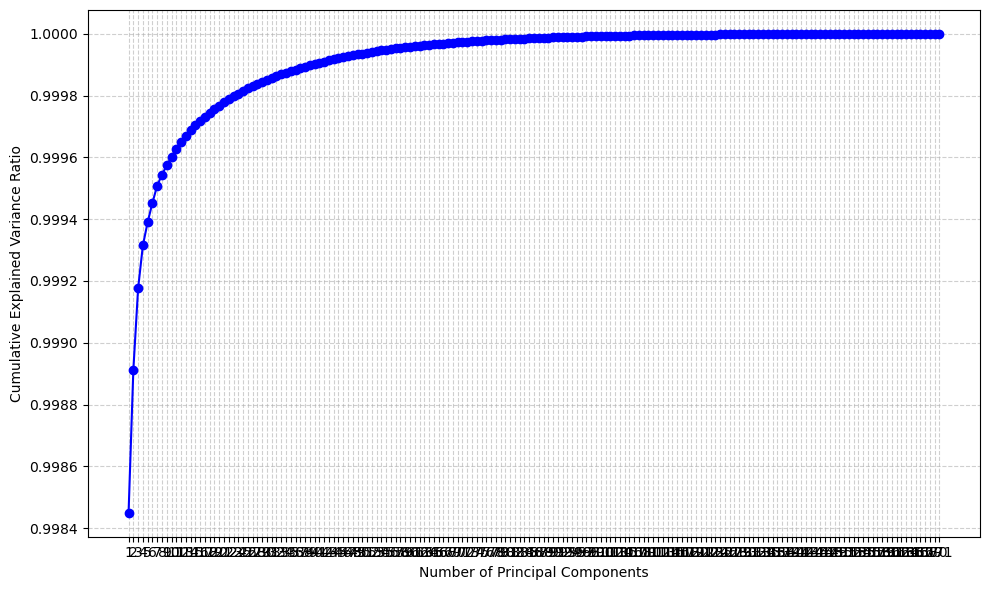


Individual Explained Variance Ratios: [0.998 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.

In [27]:
# Plot the Results (The 'Elbow Plot') --- 
plt.figure(figsize=(10, 6)) 
# Plot the individual explained variance (optional, but good for context) 
#plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center', label='Individual Explained Variance', color='gray') 
# Plot the cumulative explained variance 
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', color='blue', label='Cumulative Explained Variance') 
# Add a horizontal line for a common threshold (e.g., 90%) # The index of the component that reaches or exceeds the threshold 
target_variance = 0.90 
num_components_90 = np.argmax(cumulative_explained_variance >= target_variance) + 1 
#plt.hlines(target_variance, 1, len(cumulative_explained_variance), linestyle='--', color='red', label=f'{target_variance*100:.0f}% Threshold') 
#plt.vlines(num_components_90, 0, target_variance, linestyle=':', color='red', label=f'PCs for {target_variance*100:.0f}%') 
# Add labels and title plt.title('Cumulative Explained Variance by Principal Components 📊') 
plt.xlabel('Number of Principal Components') 
plt.ylabel('Cumulative Explained Variance Ratio') 
plt.xticks(range(1, len(cumulative_explained_variance) + 1)) 
# Ensure x-axis shows component numbers 
# Add a legend and grid plt.legend(loc='best') 
plt.grid(True, linestyle='--', alpha=0.6) 
# Add text annotation for the 90% point 
plt.annotate(f'{num_components_90} PCs = {target_variance*100:.0f}% Var', xy=(num_components_90, target_variance), xytext=(num_components_90 + 0.5, target_variance - 0.1), arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5), fontsize=10, color='red') 
plt.tight_layout() 
plt.show() 
print(f"\nIndividual Explained Variance Ratios: {explained_variance_ratio.round(3)}") 
print(f"Cumulative Explained Variance: {cumulative_explained_variance.round(3)}") 
print(f"\nTo capture {target_variance*100:.0f}% of the variance, you need **{num_components_90}** Principal Components.")



Over 90% of the variance is captured in 1 principal component. I will use two components for plotting purposes. 

In [35]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(df2000)

In [37]:
principalComponents

array([[ 5.94802048e+02, -7.67007031e+00],
       [ 5.93553382e+02, -7.62806569e+00],
       [ 5.92296033e+02, -8.15410165e+00],
       [ 5.91044753e+02, -6.96901110e+00],
       [ 5.89788745e+02, -7.94067326e+00],
       [ 5.88540256e+02, -7.09615708e+00],
       [ 5.87297360e+02, -8.16519320e+00],
       [ 5.86051304e+02, -8.56606700e+00],
       [ 5.84810791e+02, -1.05440260e+01],
       [ 5.83580382e+02, -9.77187384e+00],
       [ 5.82332484e+02, -9.39929433e+00],
       [ 5.81077520e+02, -1.06733922e+01],
       [ 5.79813220e+02, -1.13536226e+01],
       [ 5.78565886e+02, -1.04494903e+01],
       [ 5.77340183e+02, -1.07649336e+01],
       [ 5.76093506e+02, -1.04300324e+01],
       [ 5.74835873e+02, -8.40774139e+00],
       [ 5.73565826e+02, -9.12467768e+00],
       [ 5.72346628e+02, -6.38348857e+00],
       [ 5.71104387e+02, -7.26991573e+00],
       [ 5.69837708e+02, -1.02264934e+01],
       [ 5.68572964e+02, -1.17521195e+01],
       [ 5.67329752e+02, -1.27019641e+01],
       [ 5.

In [99]:
dfPCA = pd.DataFrame(principalComponents, columns=['PCA1', 'PCA2'])

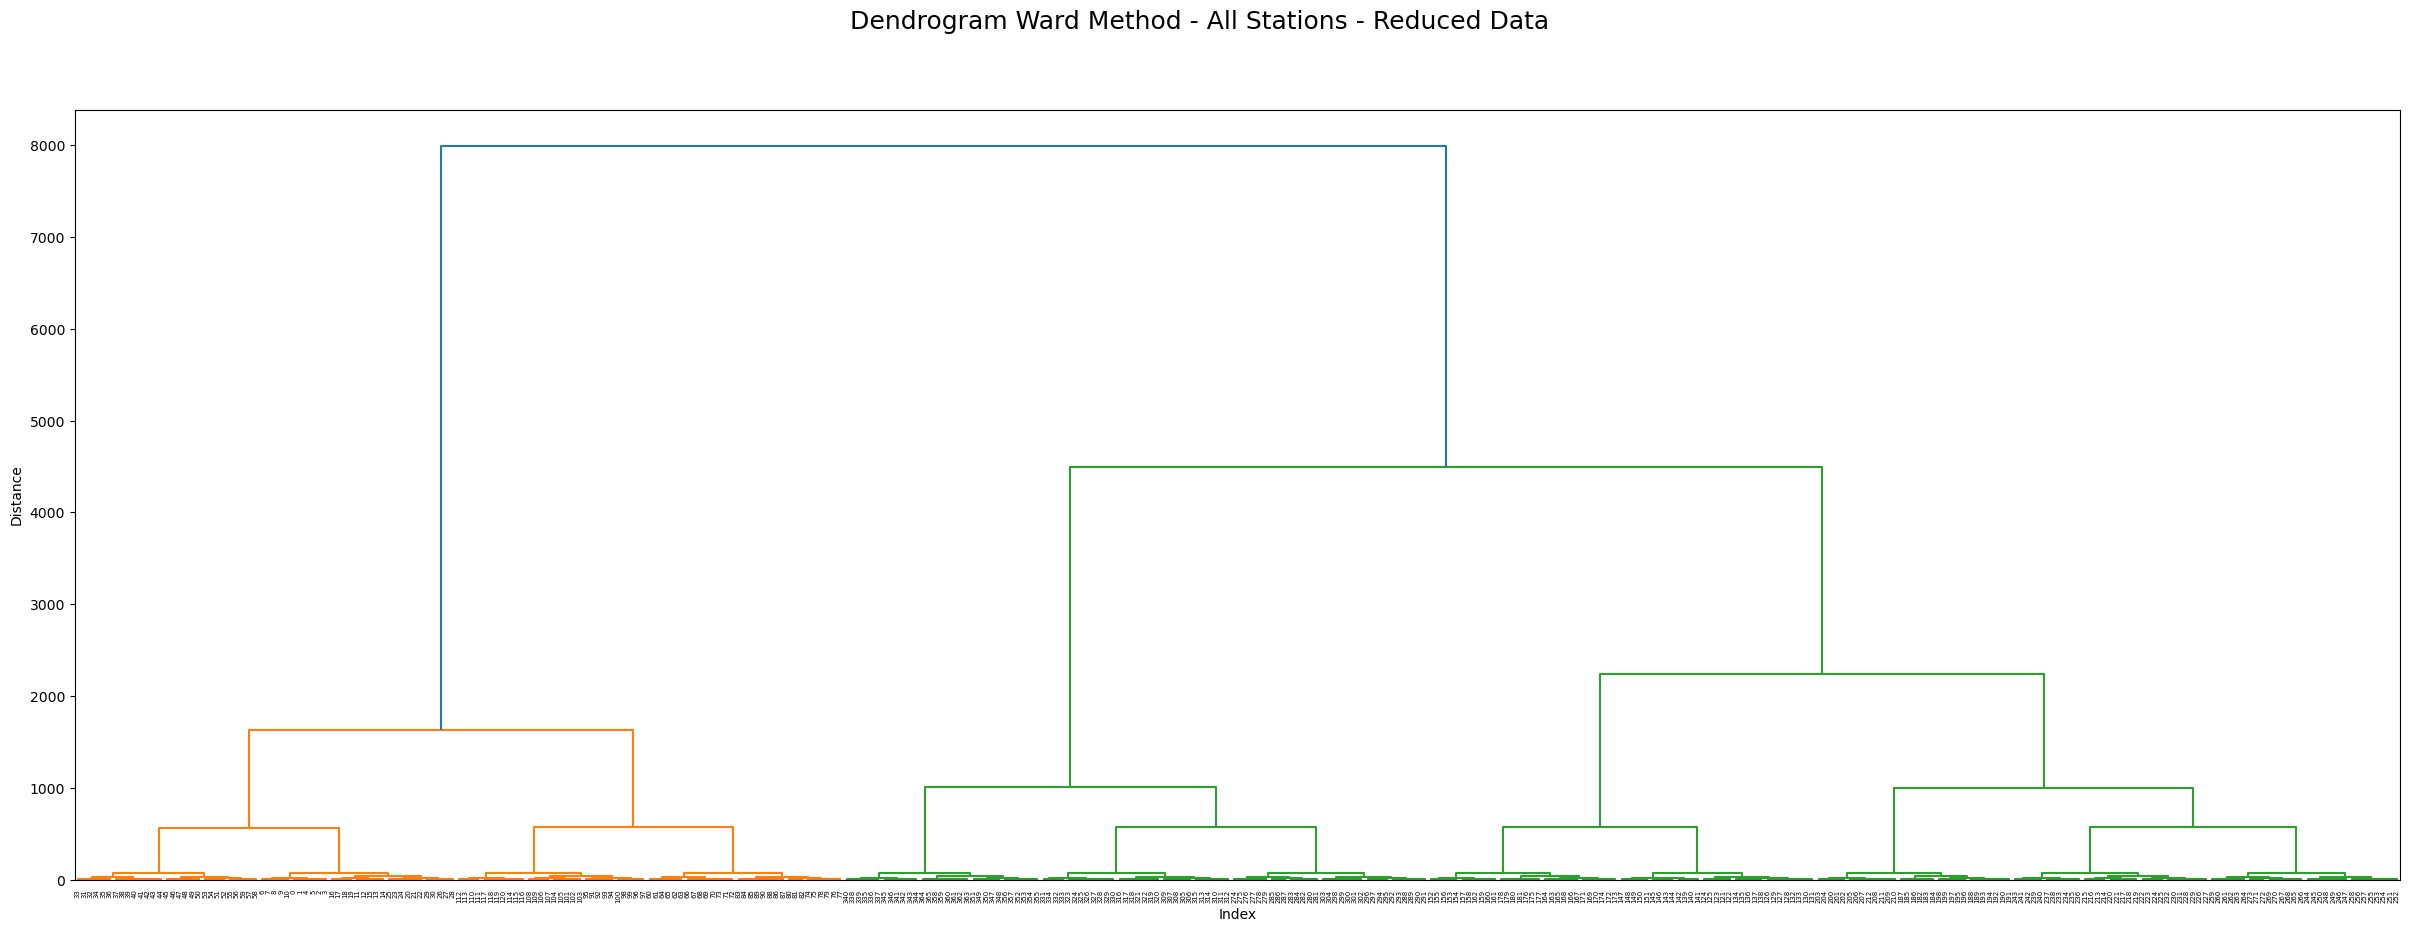

In [149]:
#Recluster using reduced dataset

distance_single_pca = linkage(dfPCA.loc[:,
['PCA1', 'PCA2']],method="ward")
plt.figure(figsize=(30,10))
dendrogram(distance_single_pca, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method - All Stations - Reduced Data",fontsize=18)
plt.show()

The reduced dataset also has two distinct clusters using the ward method. 

In [153]:
#Pull out cluster classification (cluster 1 or 2) based on where the the point lies

df_ward_pca=df2000.copy()

df_ward_pca['clust']=fcluster(distance_single_pca,2, criterion='maxclust')
#df_iris_SM['clust3']=fcluster(dist_sin,3, criterion='maxclust')
df_ward_pca.head()

,id,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,clust
14610,14610,20000101,1,1.076130,-0.02793,1.187444,1.618161,-1.229941,-0.385392,-0.179228,...,0.902363,0.863006,-1.077399,-0.372456,-0.024706,-0.829285,-1.239016,-1.585517,-0.723479,1
14611,14611,20000102,1,1.076130,-0.02793,1.006770,2.107251,-1.176243,-0.445514,-0.179228,...,1.324188,0.322318,-1.183432,0.006276,-0.024706,-1.039536,-0.337751,-0.164486,-0.838511,1
14612,14612,20000103,1,-0.170720,-0.02793,0.464749,2.046115,-0.907754,-0.445514,-0.179228,...,-0.503721,0.107908,-1.077399,0.751904,-0.024706,-0.679106,-0.638173,-0.164486,-1.039817,1
14613,14613,20000104,1,0.660514,-0.02793,0.284075,1.251344,-0.768140,0.255911,-0.179228,...,-0.925546,-0.404813,-0.912459,-0.088407,-0.024706,0.011717,-0.788384,-0.793019,-1.672492,1
14614,14614,20000105,1,-0.170720,-0.02793,1.277781,1.006799,-0.897015,-0.305229,-0.179228,...,-0.222504,-1.728565,-1.195214,-0.100243,-0.024706,-1.039536,-0.908552,-1.066294,-0.637205,1


In [155]:
dfPCA['clust_pca']  = df_ward_pca['clust'].values

In [157]:
dfPCA['clust']  = df_ward['clust'].values

In [159]:
dfPCA['label']  = ans2000['BASEL_pleasant_weather'].values

In [161]:
dfPCA

,PCA1,PCA2,clust,label,clust_pca
0,594.802048,-7.670070,2,0,1
1,593.553382,-7.628066,2,0,1
2,592.296033,-8.154102,2,0,1
3,591.044753,-6.969011,2,0,1
4,589.788745,-7.940673,2,0,1
...,...,...,...,...,...
361,-587.646889,-14.389240,2,0,2
362,-588.887275,-13.853076,2,0,2
363,-590.123671,-15.143501,2,0,2
364,-591.350204,-13.882227,2,0,2


<Axes: title={'center': 'True  Labels'}, xlabel='PCA1', ylabel='PCA2'>

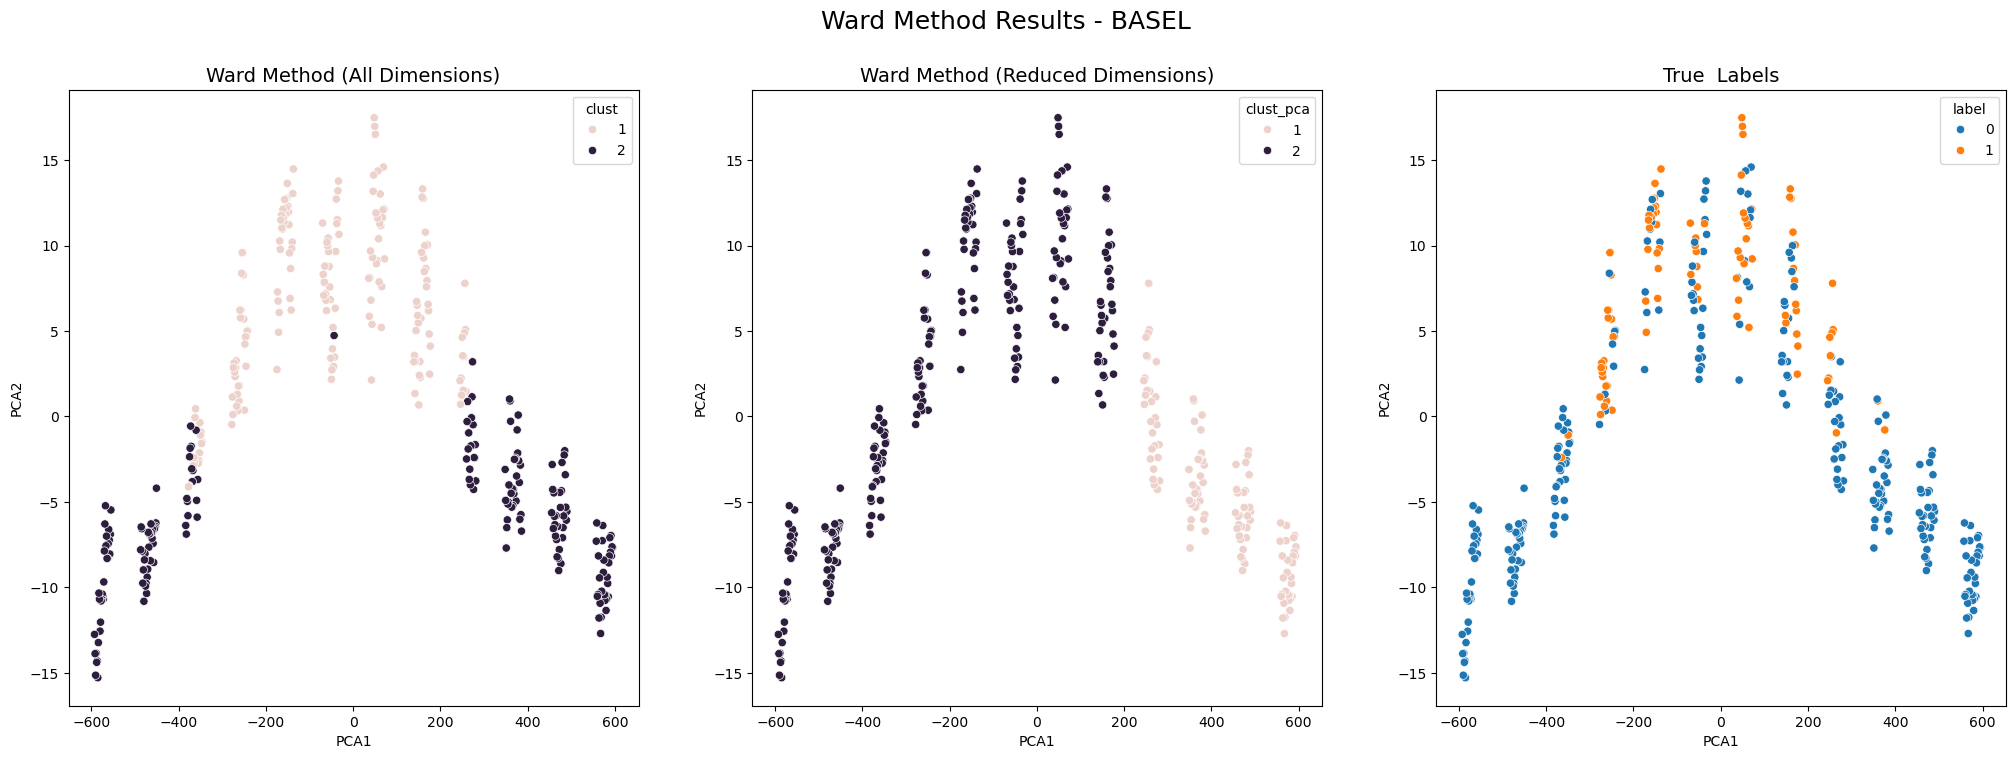

In [163]:
plt.figure(figsize=(25,8))

plt.suptitle("Ward Method Results - BASEL",fontsize=18)

plt.subplot(1,3,1)
plt.title("Ward Method (All Dimensions)",fontsize=14)
sns.scatterplot(x="PCA1",y="PCA2", data=dfPCA, hue="clust")

plt.subplot(1,3,2)
plt.title("Ward Method (Reduced Dimensions)",fontsize=14)
sns.scatterplot(x="PCA1",y="PCA2", data=dfPCA, hue="clust_pca")

plt.subplot(1,3,3)
plt.title("True  Labels",fontsize=14)
sns.scatterplot(x="PCA1",y="PCA2", data=dfPCA, hue="label")

The true labels are mixed in the higher values of PCA2. The Ward method seemed to attribute these to cluster 1 (pleasant weather) when clustering on all dimensions. Although it does not genererally pick out unpleasant weather on a granular level within the cluster. The clustering on the reduced dimensions did not perform as well. 

In [166]:
pca15 = PCA(n_components=15)
principalComponents15 = pca15.fit_transform(df2000)

In [170]:
dfPCA15 = pd.DataFrame(principalComponents15, columns=['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5','PCA6','PCA7','PCA8','PCA9','PCA10','PCA11','PCA12','PCA13','PCA14', 'PCA15'])

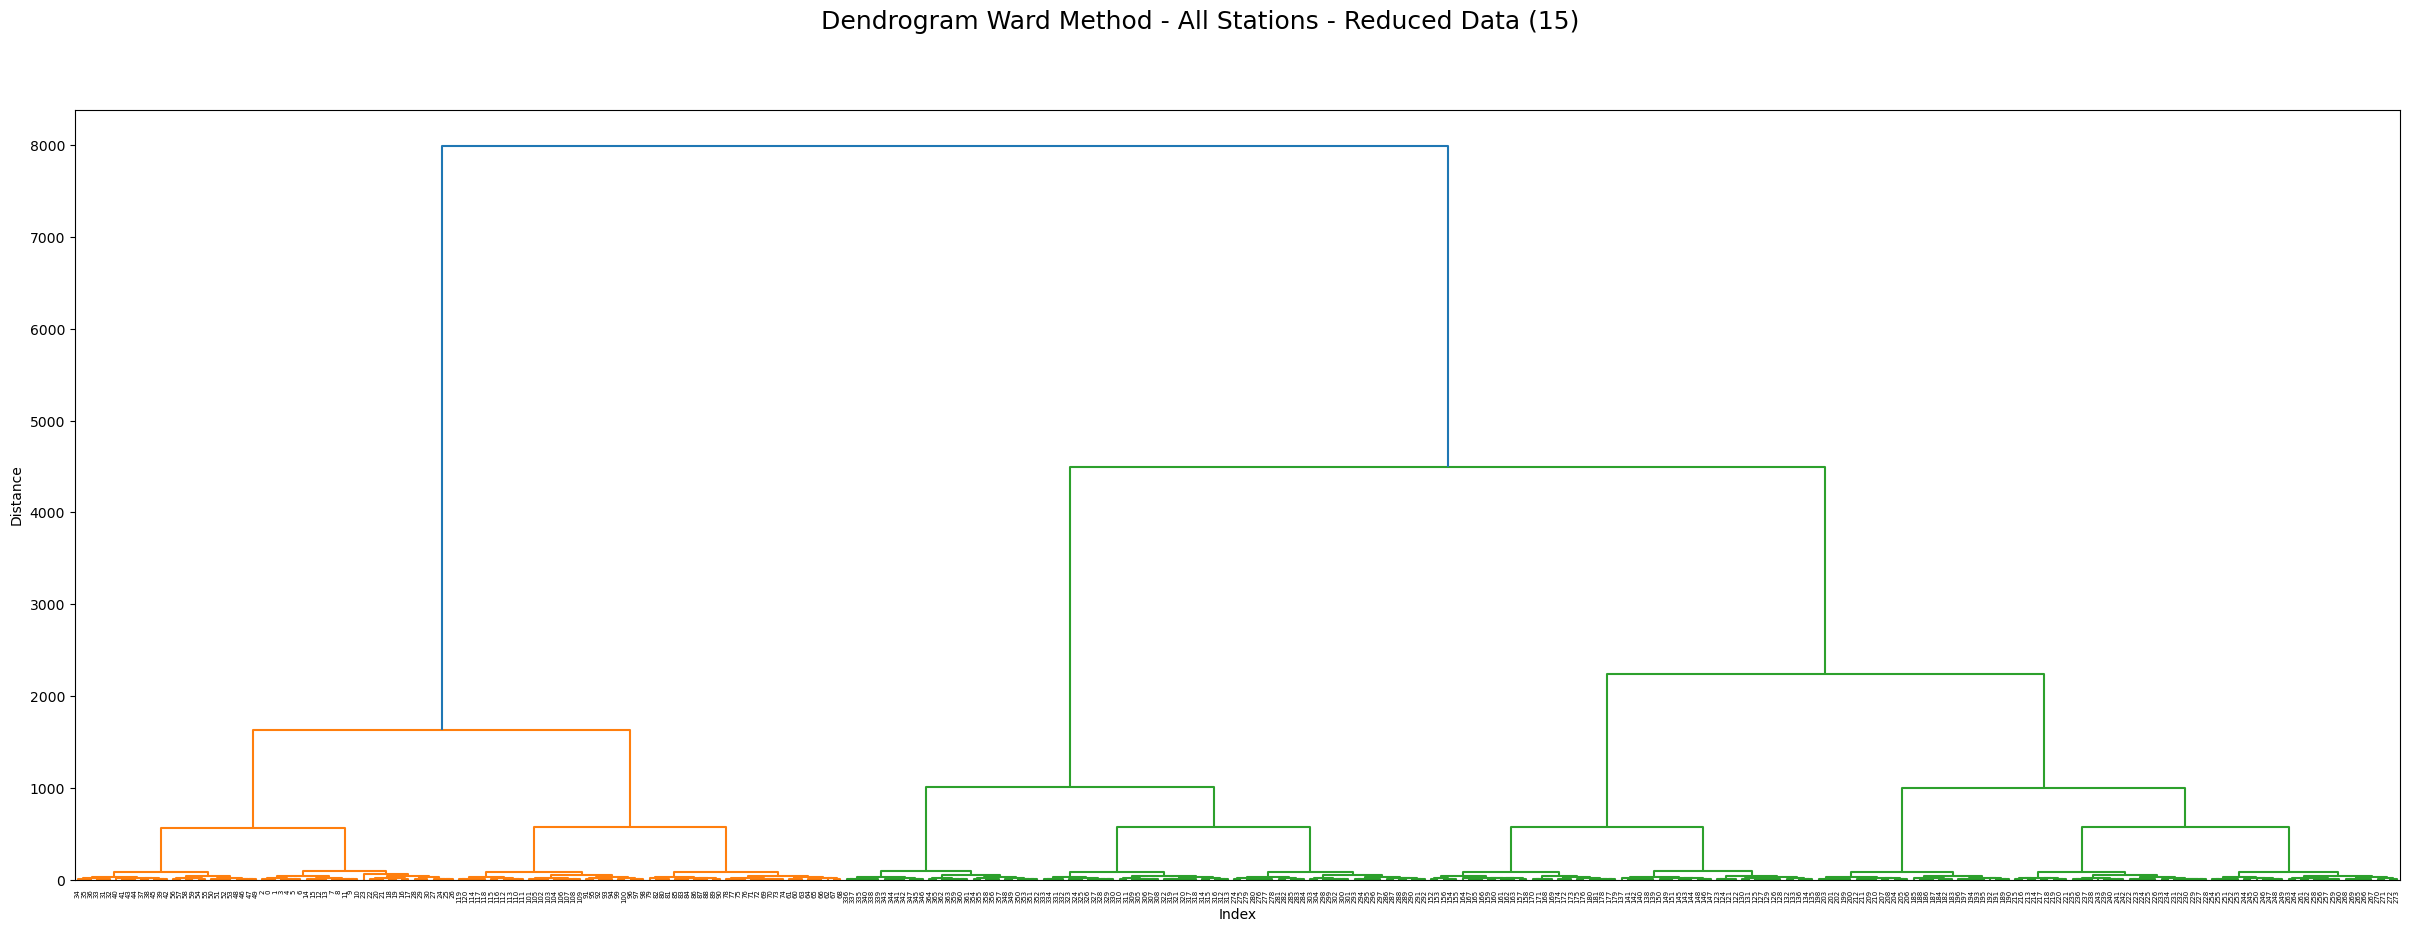

In [174]:
#Recluster using reduced dataset

distance_single_pca15 = linkage(dfPCA15.loc[:,
['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5','PCA6','PCA7','PCA8','PCA9','PCA10','PCA11','PCA12','PCA13','PCA14', 'PCA15']],method="ward")
plt.figure(figsize=(30,10))
dendrogram(distance_single_pca15, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method - All Stations - Reduced Data (15)",fontsize=18)
plt.show()

In [176]:
#Pull out cluster classification (cluster 1 or 2) based on where the the point lies

df_ward_pca15=df2000.copy()

df_ward_pca15['clust']=fcluster(distance_single_pca,2, criterion='maxclust')
#df_iris_SM['clust3']=fcluster(dist_sin,3, criterion='maxclust')
df_ward_pca15.head()

,id,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,clust
14610,14610,20000101,1,1.076130,-0.02793,1.187444,1.618161,-1.229941,-0.385392,-0.179228,...,0.902363,0.863006,-1.077399,-0.372456,-0.024706,-0.829285,-1.239016,-1.585517,-0.723479,1
14611,14611,20000102,1,1.076130,-0.02793,1.006770,2.107251,-1.176243,-0.445514,-0.179228,...,1.324188,0.322318,-1.183432,0.006276,-0.024706,-1.039536,-0.337751,-0.164486,-0.838511,1
14612,14612,20000103,1,-0.170720,-0.02793,0.464749,2.046115,-0.907754,-0.445514,-0.179228,...,-0.503721,0.107908,-1.077399,0.751904,-0.024706,-0.679106,-0.638173,-0.164486,-1.039817,1
14613,14613,20000104,1,0.660514,-0.02793,0.284075,1.251344,-0.768140,0.255911,-0.179228,...,-0.925546,-0.404813,-0.912459,-0.088407,-0.024706,0.011717,-0.788384,-0.793019,-1.672492,1
14614,14614,20000105,1,-0.170720,-0.02793,1.277781,1.006799,-0.897015,-0.305229,-0.179228,...,-0.222504,-1.728565,-1.195214,-0.100243,-0.024706,-1.039536,-0.908552,-1.066294,-0.637205,1


In [178]:
dfPCA15['clust']  = df_ward_pca15['clust'].values

<Axes: xlabel='PCA1', ylabel='PCA2'>

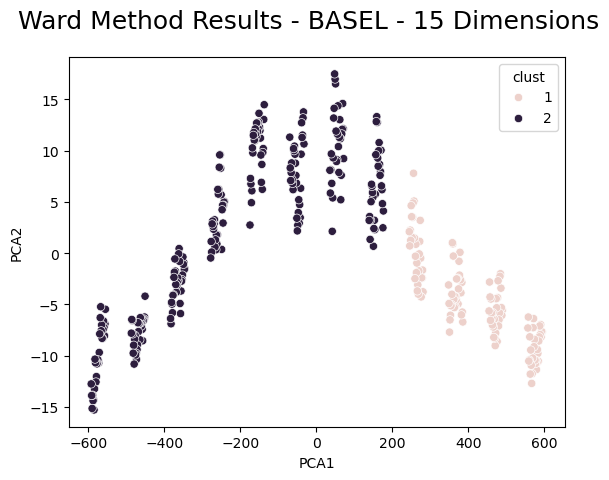

In [180]:
plt.suptitle("Ward Method Results - BASEL - 15 Dimensions",fontsize=18)
sns.scatterplot(x="PCA1",y="PCA2", data=dfPCA15, hue="clust")

Extended dimensions did not do much better.